# 量子计算基础

# 量子比特
量子比特（qubit）是量子计算的基本单位，类似于经典计算中的比特，但具有一些独特的量子特性。经典比特只能处于0或1两种状态之一，而量子比特可以同时处于0和1的叠加状态，这使得量子计算具有强大的并行计算能力
## 量子比特的表示
量子比特的状态可以用一个二维复数向量来表示：
$$
|\psi\rangle = \alpha|\text{0}\rangle + \beta|\text{1}\rangle 
$$
其中，|0⟩和|1⟩是量子比特的基态，类似于经典比特的0和1。α和β是复数，称为概率振幅，他们的模的平方代表测量该量子态时得到对应基态的概率，他们的值满足归一化条件：
$$
|\alpha|^2 + |\beta|^2 = 1
$$
## 量子比特的叠加
叠加原理是量子比特的一个核心特性。一个量子比特可以同时处于|0⟩ 和 |1⟩ 状态的叠加状态。例如：
$$
|\psi\rangle = \frac{1}{\sqrt{2}}|\text{0}\rangle + \frac{1}{\sqrt{2}}|\text{1}\rangle 
$$
这意味着测量该量子比特时有50%的概率测量出基态|0⟩，有50%的概率测量出基态|1⟩。


# 量子门
量子门是量子计算的基本操作单元，类似于经典计算中的逻辑门。量子门作用于量子比特（qubits），通过改变其状态来实现计算。
## 单量子比特门
单量子比特门对单个量子比特进行操作，下面介绍几个经典单比特量子门：
### Hadamard门（H门）
Hadamard门经常用于将基态转化为叠加态。基态$|\text{0}\rangle= \begin{bmatrix} 1 \\ 0 \end{bmatrix}，|\text{1}\rangle= \begin{bmatrix} 0 \\ 1 \end{bmatrix}$

Hadamard门的矩阵为：
$$
H = \frac{1}{\sqrt{2}}\begin{bmatrix}
1 & 1 \\
1 &-1
\end{bmatrix}
$$
对基态$|\text{0}\rangle$作用Hadamard门可得到叠加态$|\text{+}\rangle$：
$$
H|\text{0}\rangle = \frac{1}{\sqrt{2}} 
\begin{bmatrix}
1 & 1 \\
1 & -1
\end{bmatrix}\begin{bmatrix}
1 \\
0
\end{bmatrix}= \frac{1}{\sqrt{2}}\begin{bmatrix}
1 \\
1
\end{bmatrix}= \frac{|\text{1}\rangle + |\text{0}\rangle}{\sqrt{2}}=|\text{+}\rangle
$$
对基态$|\text{1}\rangle$作用Hadamard门可得到叠加态$|\text{-}\rangle$：
$$
H|\text{1}\rangle = \frac{1}{\sqrt{2}} 
\begin{bmatrix}
1 & 1 \\
1 & -1
\end{bmatrix}\begin{bmatrix}
0 \\
1
\end{bmatrix}= \frac{1}{\sqrt{2}}\begin{bmatrix}
1 \\
-1
\end{bmatrix}= \frac{|\text{1}\rangle-|\text{0}\rangle}{\sqrt{2}}=|\text{-}\rangle
$$
Hadamard门的矩阵为厄米矩阵，因此它也具备将叠加态$|\text{+}\rangle$与$|\text{-}\rangle$分别转变为基态$|\text{0}\rangle$与$|\text{1}\rangle$的能力：
$$
H|\text{+}\rangle = \frac{1}{\sqrt{2}} 
\begin{bmatrix}
1 & 1 \\
1 & -1
\end{bmatrix}\frac{1}{\sqrt{2}}\begin{bmatrix}
1 \\
1
\end{bmatrix}=\begin{bmatrix}
1 \\
0
\end{bmatrix}=|\text{0}\rangle
$$
$$ 
H|\text{-}\rangle = \frac{1}{\sqrt{2}} 
\begin{bmatrix}
1 & 1 \\
1 & -1
\end{bmatrix}\frac{1}{\sqrt{2}}\begin{bmatrix}
1 \\
-1
\end{bmatrix}=\begin{bmatrix}
0 \\
1
\end{bmatrix}=|\text{1}\rangle 
$$
Hadamard门在Deepquantum中的实现代码如下：

In [2]:
import deepquantum as dq
import numpy as np

cir = dq.QubitCircuit(1)
# 创建有一个量子比特的量子线路（初始量子比特默认处于基态|0>）
cir.h(0)
# 对出于0位的量子比特施加Hadamard门
cir()
# 运行量子线路
result = cir.measure()
print(result)
# 输出量子线路运行1024次后的结果统计 
# 例：{'0': 511, '1': 513} 代表511次测量到|0>态，513次测量到|1>态

{'1': 497, '0': 527}


展示量子线路：

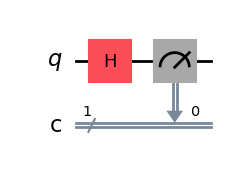

In [3]:
cir.draw()

### 泡利门（Pauli gates）
泡利门（Pauli gates）是量子计算中的基本量子门，它们以物理学家沃尔夫冈·泡利（Wolfgang Pauli）的名字命名。泡利门包括三个单量子比特门：Pauli-X门、Pauli-Y门和 Pauli-Z门。每个泡利门对应一个 2x2 的厄米矩阵（Hermitian matrix）。下面我会详细介绍这三个泡利门。

Pauli-X门，又叫做X门或NOT门，是量子计算中的基本量子门之一。它的作用类似于经典计算中的NOT门，会将一个量子比特的量子态翻转。

Pauli-X门的矩阵为：
$$
X = \begin{bmatrix}
0 & 1 \\
1 & 0
\end{bmatrix}
$$ 

Pauli-X门对|0>和|1>态的作用如下：
$$
X|\text{0}\rangle = \begin{bmatrix}
0 & 1 \\
1 & 0
\end{bmatrix}\begin{bmatrix}
1\\
0
\end{bmatrix}=\begin{bmatrix}
0\\
1
\end{bmatrix}=|\text{1}\rangle
$$ 
$$
X|\text{1}\rangle = \begin{bmatrix}
0 & 1 \\
1 & 0
\end{bmatrix}\begin{bmatrix}
0\\
1
\end{bmatrix}=\begin{bmatrix}
1\\
0
\end{bmatrix}=|\text{0}\rangle
$$ 
Pauli-Y门,又叫做Y门，在翻转量子比特的同时将其相位改变。

Pauli-Y门的矩阵为：
$$
Y = \begin{bmatrix}
0 & -i \\
i & 0
\end{bmatrix}
$$ 
Pauli-Y门对|0>和|1>态的作用如下：
$$
Y|\text{0}\rangle = \begin{bmatrix}
0 & -i \\
i & 0
\end{bmatrix}\begin{bmatrix}
1\\
0
\end{bmatrix}=\begin{bmatrix}
0\\
i
\end{bmatrix}=i|\text{1}\rangle
$$ 
$$
Y|\text{1}\rangle = \begin{bmatrix}
0 & -i \\
i & 0
\end{bmatrix}\begin{bmatrix}
0\\
1
\end{bmatrix}=\begin{bmatrix}
-i\\
0
\end{bmatrix}=-i|\text{0}\rangle
$$ 
Pauli-Z门又叫Z门，会对量子比特的∣1⟩ 态引入一个相位因子−1，而对∣0⟩ 态不做任何改变。

Pauli-Z门的矩阵为：
$$
Z = \begin{bmatrix}
1 & 0 \\
0 & -1
\end{bmatrix}
$$ 
Pauli-Z门对|0>和|1>态的作用如下：
$$
Z|\text{0}\rangle = \begin{bmatrix}
1 & 0 \\
0 & -1
\end{bmatrix}\begin{bmatrix}
1\\
0
\end{bmatrix}=\begin{bmatrix}
1\\
0
\end{bmatrix}=|\text{0}\rangle
$$ 
$$
Z|\text{1}\rangle = \begin{bmatrix}
1 & 0 \\
0 & -1
\end{bmatrix}\begin{bmatrix}
0\\
1
\end{bmatrix}=\begin{bmatrix}
0\\
-1
\end{bmatrix}=-|\text{1}\rangle
$$ 
X门、Y门和Z门都可以由其他两种门共同作用得到，$iX=YZ$,$iY=ZX$，$iZ=XY$,下面我们利用Deepquantum检验以上关系：

In [4]:
x = dq.PauliX()
x.matrix
# 展示X门矩阵

tensor([[0.+0.j, 1.+0.j],
        [1.+0.j, 0.+0.j]])

In [5]:
y = dq.PauliY()
y.matrix
# 展示Y门矩阵

tensor([[0.+0.j, -0.-1.j],
        [0.+1.j, 0.+0.j]])

In [6]:
z = dq.PauliZ()
z.matrix
# 展示Z门矩阵

tensor([[ 1.+0.j,  0.+0.j],
        [ 0.+0.j, -1.+0.j]])

In [7]:
print(complex(0, 1)*x.matrix,"\n",y.matrix @ z.matrix)
# 第一行输出iX的矩阵；第二行输出YZ的矩阵。比较二者是否相同

tensor([[0.+0.j, 0.+1.j],
        [0.+1.j, 0.+0.j]]) 
 tensor([[0.+0.j, 0.+1.j],
        [0.+1.j, 0.+0.j]])


In [8]:
print(complex(0, 1)*y.matrix,"\n",z.matrix @ x.matrix)
# 第一行输出iY的矩阵；第二行输出ZX的矩阵。比较二者是否相同

tensor([[ 0.+0.j,  1.-0.j],
        [-1.+0.j,  0.+0.j]]) 
 tensor([[ 0.+0.j,  1.+0.j],
        [-1.+0.j,  0.+0.j]])


In [9]:
print(complex(0, 1)*z.matrix,"\n",x.matrix @ y.matrix)
# 第一行输出iZ的矩阵；第二行输出XY的矩阵。比较二者是否相同

tensor([[0.+1.j, 0.+0.j],
        [0.+0.j, -0.-1.j]]) 
 tensor([[0.+1.j, 0.+0.j],
        [0.+0.j, 0.-1.j]])


### 旋转门
量子计算中的任意角度旋转门是一类重要的量子门，它允许我们在量子比特上以任意角度旋转。这些门通常用于量子算法中的各种操作，如量子相位估计、量子傅里叶变换等。

绕X轴旋转的量子门$R_x(\theta)$矩阵表达为：
$$
R_x(\theta) = \begin{bmatrix}
cos(\frac{\theta}{2}) & -isin(\frac{\theta}{2}) \\
-isin(\frac{\theta}{2}) & cos(\frac{\theta}{2})
\end{bmatrix}
$$
绕Y轴旋转的量子门$R_y(\theta)$矩阵表达为：
$$
R_y(\theta) = \begin{bmatrix}
cos(\frac{\theta}{2}) & -sin(\frac{\theta}{2}) \\
sin(\frac{\theta}{2}) & cos(\frac{\theta}{2})
\end{bmatrix}
$$
绕Z轴旋转的量子门$R_z(\theta)$矩阵表达为：
$$
R_z(\theta) = \begin{bmatrix}
e^{-i\frac{\theta}{2}} & 0 \\
0 & e^{i\frac{\theta}{2}}
\end{bmatrix}
$$
当$\theta=\pi$，旋转门$R_x(\theta)$、$R_y(\theta)$和$R_z(\theta)$分别等价于X门、Y门和Z门。下面我们利用Deepquantum进行验证：

In [10]:
cir = dq.QubitCircuit(6)
cir.rx(0, np.pi)
cir.x(1)
cir.ry(2, np.pi)
cir.y(3)
cir.rz(4, np.pi)
cir.z(5)
cir()
result = cir.measure()
print(result)

{'111100': 1024}


### S门
S门，也被称为相位门（Phase Gate），是量子计算中的一个重要的单量子比特门。它主要用来改变量子比特的相位，而不会改变其概率分布。S门在量子算法中扮演着关键角色，尤其是在那些需要进行相位编码的算法中。

S门的矩阵形式如下：
$$
S = \begin{bmatrix}
1 & 0 \\
0 & i
\end{bmatrix}
$$ 
S门对$|\text{0}\rangle$和$|\text{1}\rangle$态的作用如下：
$$
S|\text{0}\rangle = \begin{bmatrix}
1 & 0 \\
0 & i
\end{bmatrix}\begin{bmatrix}
1\\
0
\end{bmatrix}=\begin{bmatrix}
1\\
0
\end{bmatrix}=|\text{0}\rangle
$$ 
$$
S|\text{1}\rangle = \begin{bmatrix}
1 & 0 \\
0 & i
\end{bmatrix}\begin{bmatrix}
0\\
1
\end{bmatrix}=\begin{bmatrix}
0\\
i
\end{bmatrix}=i|\text{1}\rangle
$$ 
S门是Z门的平方根，即$Z=SS$。下面展示Deepquantum中S门的矩阵并验证上述关系：


In [11]:
s = dq.SGate()
s.matrix

tensor([[1.+0.j, 0.+0.j],
        [0.+0.j, 0.+1.j]])

In [12]:
cir = dq.QubitCircuit(2, init_state=[1, 0, 0, 0])
# 设定量子线路起始态为[1,0,0,0]，即|00>态；可以改为[0,0,0,1]，尝试以|11>态起始的结果
cir.z(0)
# 对第0位量比特作用Z门
cir.s(1)
cir.s(1)
# 对第1位量子比特作用两次S门
cir()
# 运行量子线路
print(cir.measure())
# 观测两个量子比特的量子态1024次，记录结果

{'00': 1024}


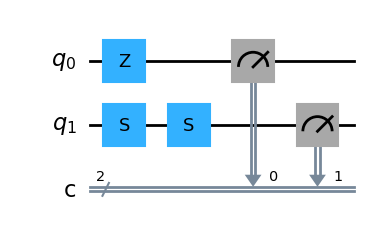

In [13]:
cir.draw()
# 绘制量子线路

### T门
T门（T-gate）也称为$\frac{\pi}{8}$门或sqrt(S)门是量子计算中使用的一种单量子比特门，主要用于改变量子比特的相位。

T门矩阵形式如下：
$$
T = \begin{bmatrix}
1 & 0 \\
0 & e^{i\frac{\pi}{4}}
\end{bmatrix}
$$ 
T门是S门的平方根，即$S=TT$。下面展示Deepquantum中S门的矩阵并验证上述关系：

In [14]:
t = dq.TGate()
t.matrix

tensor([[1.0000+0.0000j, 0.0000+0.0000j],
        [0.0000+0.0000j, 0.7071+0.7071j]])

In [15]:
cir = dq.QubitCircuit(2)
cir.s(0)
cir.t(1)
cir.t(1)
cir()
print(cir.measure())

{'00': 1024}


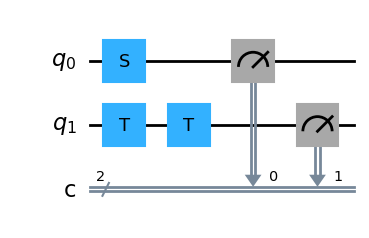

In [16]:
cir.draw()

## 双量子比特门
双量子比特门允许我们对两个量子比特进行控制，这是构建复杂量子线路的基础。
### CNOT门
CNOT门（Controlled-NOT门）是量子计算中最基本的两量子比特门之一。CNOT门有两个量子比特输入，一个称为控制量子比特（Control），另一个称为目标量子比特（Target）。

CNOT门的矩阵表示为：
$$
CNOT = \begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0 \\
\end{bmatrix}
$$

当控制比特的量子态为$|\text{1}\rangle$时CNOT门会将受控比特的量子态反转。

作用解释：

对于$|\text{00}\rangle$态，保持不变：
$$
CNOT|\text{00}\rangle= \begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0 \\
\end{bmatrix}\begin{bmatrix}
1\\
0\\
0\\
0\\
\end{bmatrix}=\begin{bmatrix}
1\\
0\\
0\\
0\\
\end{bmatrix}=|\text{00}\rangle
$$
对于$|\text{01}\rangle$态，保持不变：
$$
CNOT|\text{01}\rangle= \begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0 \\
\end{bmatrix}\begin{bmatrix}
0\\
1\\
0\\
0\\
\end{bmatrix}=\begin{bmatrix}
0\\
1\\
0\\
0\\
\end{bmatrix}=|\text{01}\rangle
$$
对于$|\text{10}\rangle$态，将目标比特翻转：
$$
CNOT|\text{10}\rangle= \begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0 \\
\end{bmatrix}\begin{bmatrix}
0\\
0\\
1\\
0\\
\end{bmatrix}=\begin{bmatrix}
0\\
0\\
0\\
1\\
\end{bmatrix}=|\text{11}\rangle
$$
对于$|\text{11}\rangle$态，将目标比特翻转：
$$
CNOT|\text{11}\rangle= \begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0 \\
\end{bmatrix}\begin{bmatrix}
0\\
0\\
0\\
1\\
\end{bmatrix}=\begin{bmatrix}
0\\
0\\
1\\
0\\
\end{bmatrix}=|\text{10}\rangle
$$
对于一般的两比特量子态$|\psi\rangle=a|00\rangle+b|\text{01}\rangle+c|\text{10}\rangle+d|\text{11}\rangle$：
$$
|\psi'\rangle=CNOT|\psi\rangle= \begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0 \\
\end{bmatrix}\begin{bmatrix}
a\\
b\\
c\\
d\\
\end{bmatrix}=\begin{bmatrix}
a\\
b\\
d\\
c\\
\end{bmatrix}=a|\text{00}\rangle+b|\text{01}\rangle+d|\text{10}\rangle+c|\text{11}\rangle
$$

In [17]:
cir = dq.QubitCircuit(2, init_state=[0, 0, 1, 0])
# 设定一个初态为|10>的双量子比特线路,也可以改成其他初态尝试效果
cir.cnot(0,1)
# 设置CNOT门，第0位量子比特为控制比特，第1位量子比特为目标比特
cir()
# 运行量子线路
print(cir.measure())
# 打印量子线路的测量结果

{'11': 1024}


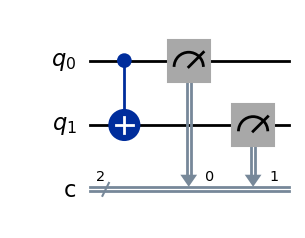

In [18]:
cir.draw()

### 受控门
Deepquantum允许使用者构建受控门，即在控制比特为$|\text{1}\rangle$态的情况下对目标比特进行某种门操作，请注意在真实量子线路中这种操作只被允许在相邻量子比特间进行。

受控X门等价于CNOT门，其矩阵与CNOT门相同：
$$
CX = \begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0 \\
\end{bmatrix}
$$
同理也有受控Y门、受控Z门和受控H门，他们的矩阵如下：
$$
CY = \begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & -i \\
0 & 0 & i & 0 \\
\end{bmatrix}
$$
$$
CZ = \begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & -1 \\
\end{bmatrix}
$$
$$
CH = \begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\
0 & 0 & \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} \\
\end{bmatrix}
$$

下面我们利用Deepquantum验证CX门与CNOT门相同：

In [19]:
cir = dq.QubitCircuit(2, init_state=[0, 0, 1, 0])
# 设定一个初态为|10>的双量子比特线路,也可以改成其他初态尝试效果
cir.cx(0,1)
# 设置CX门，第0位量子比特为控制比特，第1位量子比特为目标比特
cir()
# 运行量子线路
print(cir.measure())
# 打印量子线路的测量结果

{'11': 1024}


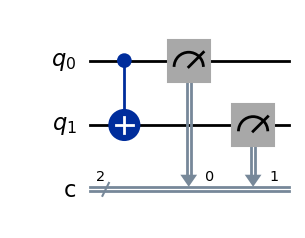

In [20]:
cir.draw()


### SWAP门
SWAP门可以将两个量子比特的状态进行交换，而不影响其他量子比特。如果有两个量子比特A和B，它们可以处于任意的量子态，SWAP门将它们的状态互换。

SWAP门的矩阵如下：
$$
SWAP = \begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
\end{bmatrix}
$$
对于一般的两比特量子态$|\psi\rangle=|\psi_A\rangle\otimes|\psi_B\rangle=(a|\text{0}\rangle)+b|\text{1}\rangle\otimes(c|\text{0}\rangle+d|\text{1}\rangle)=ac|\text{00}\rangle+ad|\text{01}\rangle+bc|\text{10}\rangle+bd|\text{11}\rangle$：
$$
|\psi'\rangle=SWAP|\psi\rangle= \begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
\end{bmatrix}\begin{bmatrix}
ac\\
ad\\
bc\\
bd\\
\end{bmatrix}=\begin{bmatrix}
ac\\
bc\\
ad\\
bd\\
\end{bmatrix}=(c|\text{0}\rangle+d|\text{1}\rangle)\otimes(a|\text{0}\rangle+b|\text{1}\rangle)=|\psi_B\rangle\otimes|\psi_A\rangle
$$
SWAP可以由三个CX门构成，下面我们利用Deepquantum进行验证：

In [21]:
cir = dq.QubitCircuit(2, init_state=[0, 0, 1, 0])
# 设定一个初态为|10>的双量子比特线路,也可以改成其他初态尝试效果
cir.swap([0,1])
# 设置CX门，第0位量子比特为控制比特，第1位量子比特为目标比特
cir()
# 运行量子线路
print(cir.measure())
# 打印量子线路的测量结果

{'01': 1024}


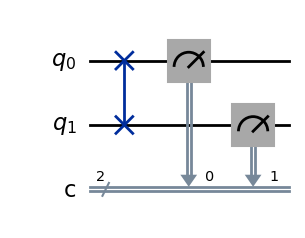

In [22]:
cir.draw()

然后我们再对线路应用三个CX门

In [23]:
cir.cx(0,1)
cir.cx(1,0)
cir.cx(0,1)
# 注意这里三个CX门的控制比特区别
cir()
print(cir.measure())

{'10': 1024}


这说明三个CX门也可以将两个量子比特的态交换

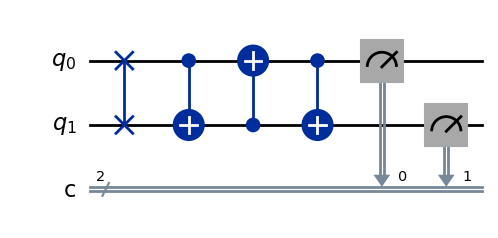

In [24]:
cir.draw()

## 多量子门
### 量子门的普适性（universality）
在对具体的多量子门进行介绍之前，我们首先介绍量子门的普适性概念，这是构建任意多量子门的理论基础。量子门的普适性（universality）是指量子计算机能够通过有限集合中的量子门的组合实现任意量子门。量子门的普适性意味着任何量子计算任务都可以分解为一系列基本量子门的操作。因此，设计一种量子计算机，只需要确保它能够实现这些基本量子门就可以执行任意量子算法。这使得量子计算机的构建更加实际和可行，同时也提供了一个通用的框架来分析和设计量子算法。

在经典计算中，AND、OR和NOT门的组合可以实现任何布尔函数，形成经典计算的普适门集合。同样，在量子计算中，有一些基本量子门的组合可以用来构建任意的量子电路，形成普适量子门集合。普适量子门集合（universal quantum gate set）的定义是指一组量子门，通过有限次的组合和应用，可以近似任意量子运算（即任意的酉操作）到任意精度。

对于量子门而言，H门、S门、T门和CNOT门构成一个普适量子门集合。普适量子门集合不止一种，具体选取那些门来实现量子计算与硬件平台相关，一般会采取该平台易于实现的基本量子门操作拟合其他复杂量子门。

### Toffoli门
Toffoli门，也称为CCNOT门，是一种在量子计算中使用的三量子比特门。它是量子计算中最基本的多量子比特门之一，经常用于构造更复杂的量子算法。Toffoli门是一个条件性门，它接受三个量子比特作为输入。如果前两个量子比特都处于状态$|1\rangle$，则Toffoli门将第三个量子比特翻转，即从$|0\rangle$变为$|1\rangle$，或从$|1\rangle$变为$|0\rangle$。Toffoli门在量子算法中扮演着重要角色，例如在量子傅里叶变换算法和用于大数质因数分解的Shor算法中。

Toffoli门的矩阵表达为：
$$
U_\text{Toffoli} = \begin{bmatrix}
1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 \\
0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 \\
\end{bmatrix}
$$
量子Toffoli门是对经典计算中Toffoli门逻辑功能的实现，经典Toffoli门的构建目的是建立可逆的逻辑电路，在经典计算中，每次不可逆的计算（如传统的AND、OR门）都会不可避免地产生能量耗散，根据Landauer原理，每丢失1比特信息会产生至少$kTln2$的热量耗散，而可逆计算不会丢失信息，因此在理论上可以实现零能量耗散。这对于降低能耗、提高计算效率具有重要意义。在量子计算中，许多量子算法（如Shor算法、Grover算法）依赖于可逆计算来保持量子叠加态和量子纠缠。

下面我们利用Deepquantum构建一个带有Toffoli门的量子线路：

In [25]:
cir = dq.QubitCircuit(3, init_state=[0, 0, 0, 0, 0, 0, 1, 0])
# 初态为|110>，可以尝试改变他观察不同的结果
cir.toffoli(0, 1, 2)
cir()
print(cir.measure())

{'111': 1024}


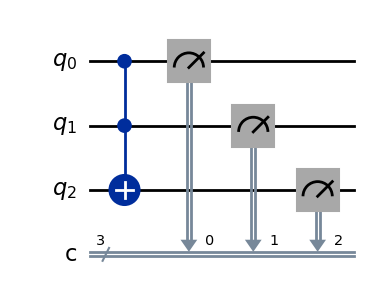

In [26]:
cir.draw()

### Fredkin门

Fredkin门，也称为控制交换门或$C_\text{SWAP}$门，是一种三量子比特的量子门，它在量子计算中具有重要的作用。与Toffoli门类似，Fredkin门也是一种条件性操作的门，但其作用是交换两个量子比特的状态，而不是翻转它们。

Fredkin门接受三个量子比特作为输入，如果第一个量子比特（控制比特）处于$|1\rangle$状态，它将交换第二和第三个量子比特的状态。

Fredkin门的矩阵形式如下：
$$
U_\text{Fredkin} = \begin{bmatrix}
1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 \\
\end{bmatrix}
$$
Fredkin门的主要作用是实现条件性交换，这在某些量子算法中非常有用，例如在量子纠错和量子通信协议中。Fredkin门是Toffoli门的逻辑对偶，下面我们利用Deepquantum构建一个带有Toffoli门的量子线路：

In [27]:
cir = dq.QubitCircuit(3, init_state=[0, 0, 0, 0, 0, 0, 1, 0])
# 初态为|110>，可以尝试改变他观察结果
cir.fredkin(0, 1, 2)
cir()
print(cir.measure())

{'101': 1024}


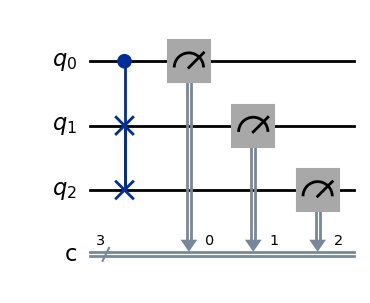

In [28]:
cir.draw()